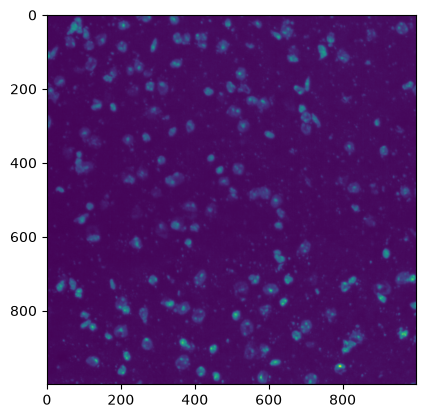

In [2]:
#13.1 - plot one image _ DAPI
from skimage.io import imread
import matplotlib.pyplot

from skimage import io as io
import matplotlib.pyplot as plt
PATH = '/Users/chann/Downloads/F1 Systems bio/Project/code/realistic_data/selected-tiles/out_opt_flow_registered_X10_Y10_c02_DAPI.tif'
im = io.imread(PATH) #read # misunderstanding(package and module)
plt.imshow(im) #draw
plt.show() #show



loaded 24 image


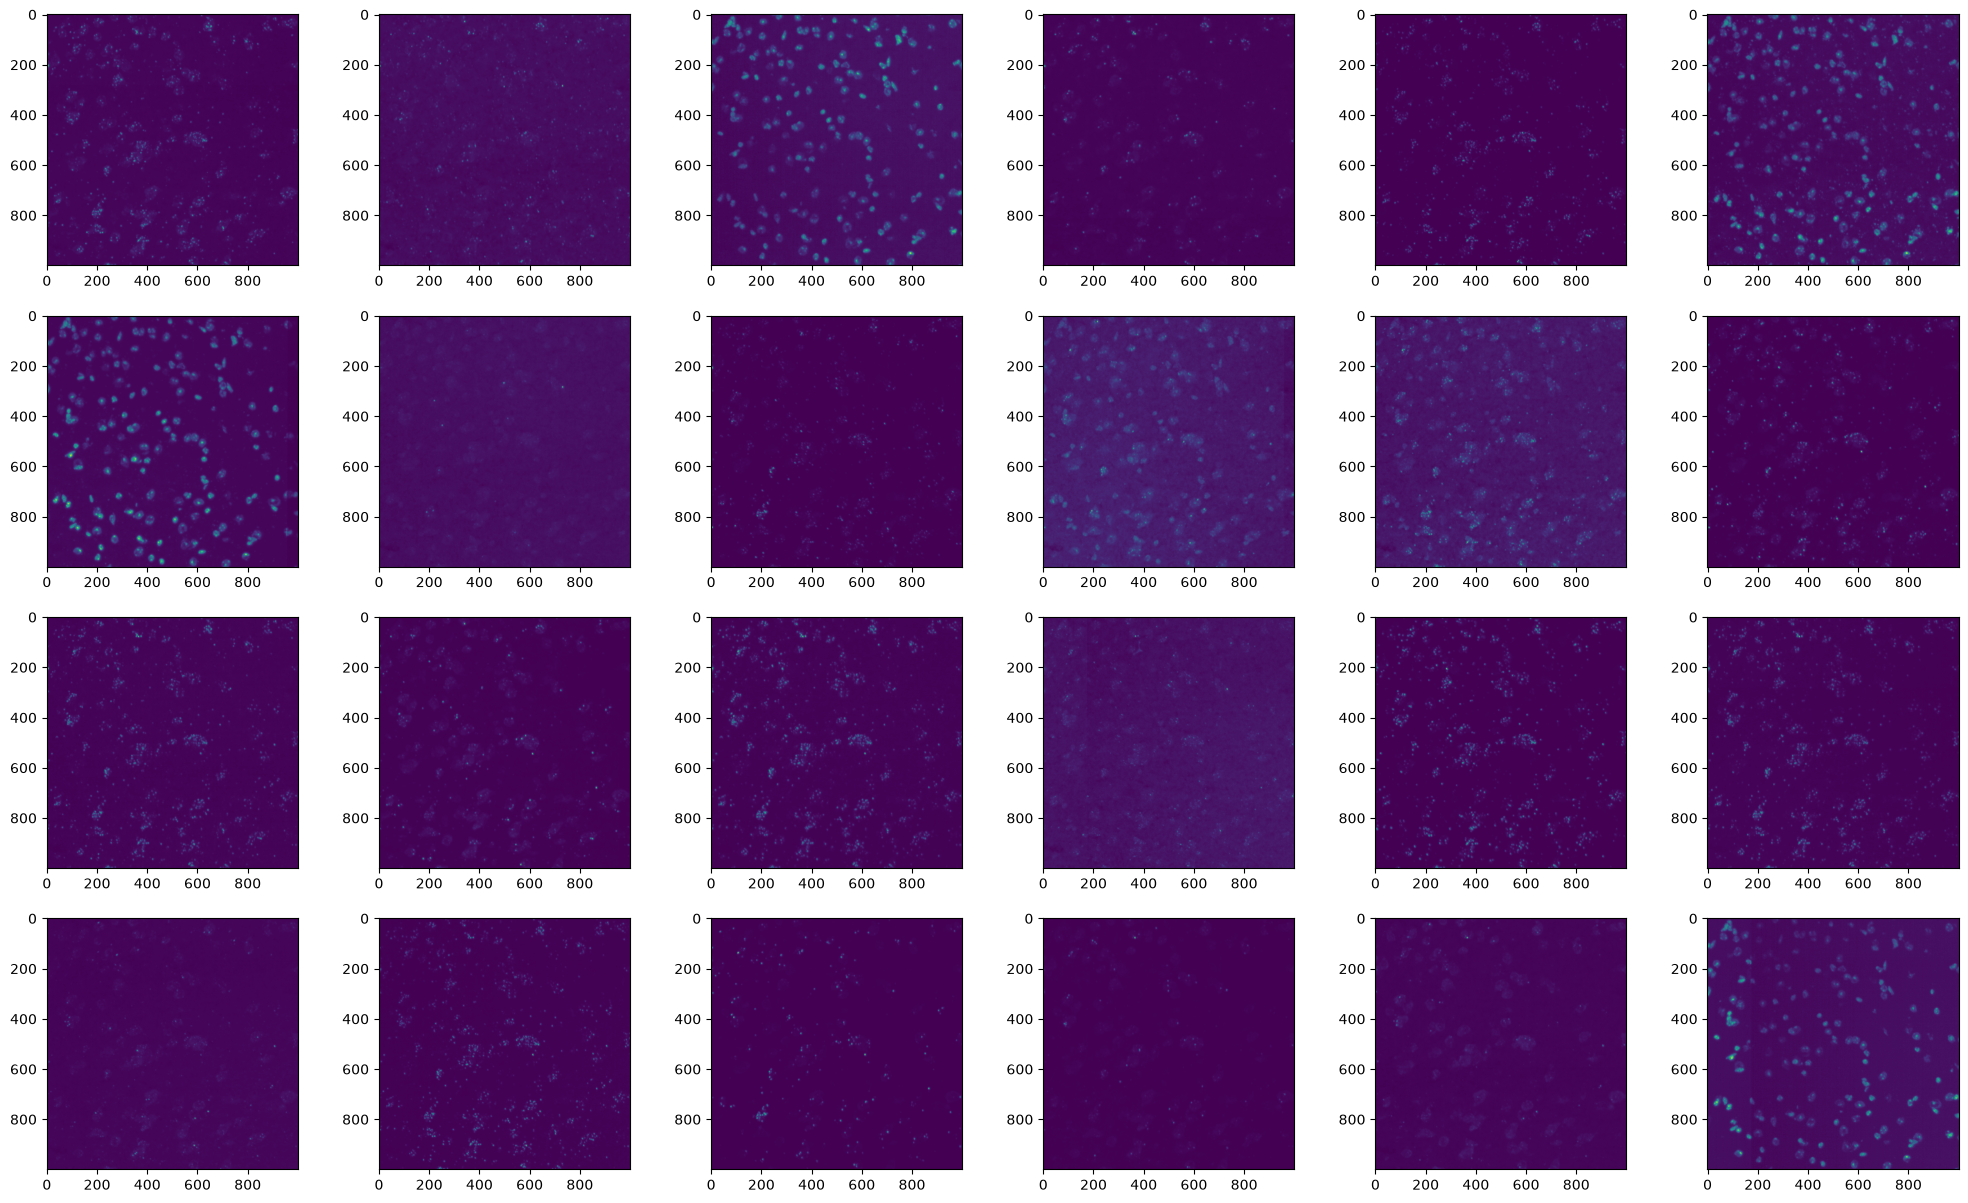

In [3]:
#13.2 + 13.3 - plot a grid of images - X10Y10
import glob
import skimage as ski
PATH = '/Users/chann/Downloads/F1 Systems bio/Project/code/realistic_data/selected-tiles/'
file_list = glob.glob('/Users/chann/Downloads/F1 Systems bio/Project/code/realistic_data/selected-tiles/out_opt_flow_registered_X10_Y10_*.tif')
file_list = glob.glob(f'{PATH}/out_opt_flow_registered_X10_Y10_*.tif')

#Create the list
list_image = []
for file in file_list:
    img = ski.io.imread(file) #readfile
    list_image.append(img)

print(f"loaded {len(list_image)} image")

#Show the list of images
import matplotlib.pyplot as plt
fig, axs = plt.subplots(4, 6, figsize=(25, 15))
for i, ax in enumerate(axs.flatten()):
    ax.imshow(list_image[i])
plt.show()

Work flow in image analysis<br>
1. read image
2. fiter - clean background
3. histogram - threshold - binary image
4. watershed - refinement
5. ID - count - number

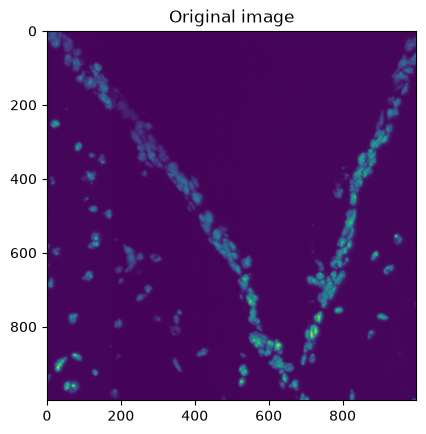

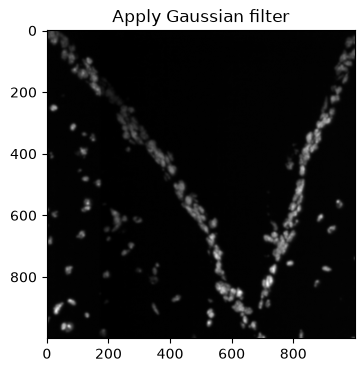

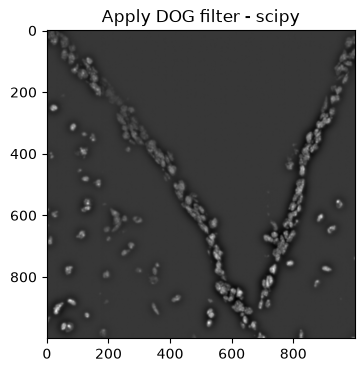

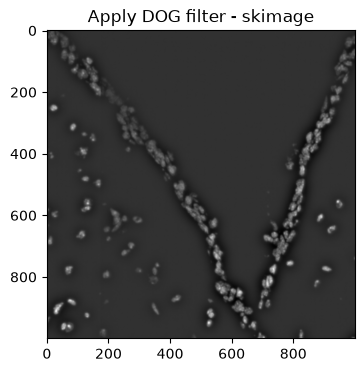

98.0 1303.0 float32


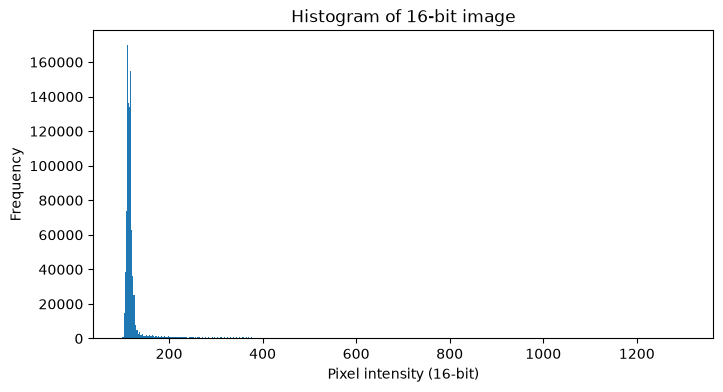

<Figure size 800x400 with 0 Axes>

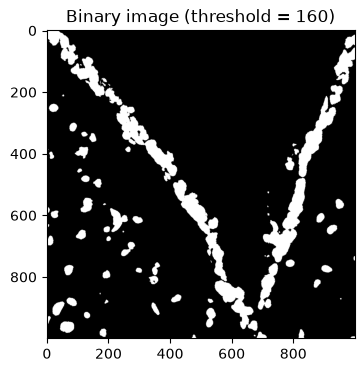

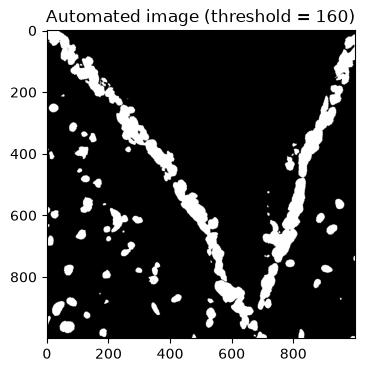

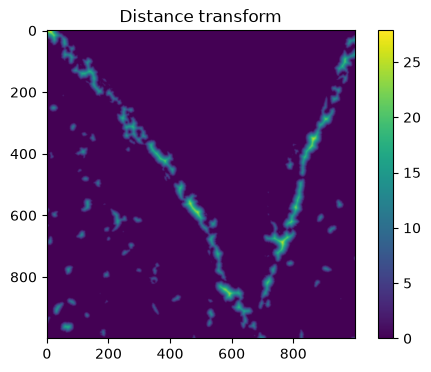

Number of markers: 137


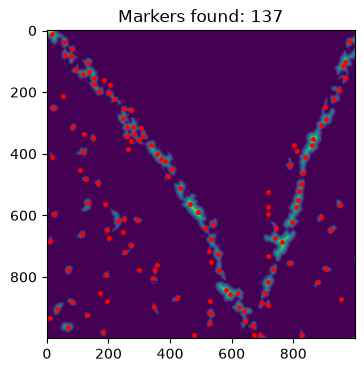

Number of object after watershed: 137


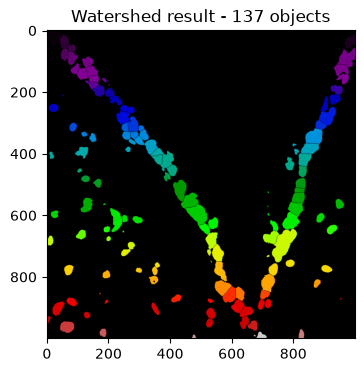

Number of object after watershed: 908


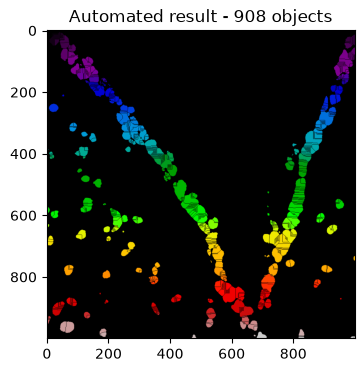

   label          y          x   area
0      1  13.616197   4.619718  284.0
1      2   5.304878  20.585366   82.0
2      3   8.048387  22.064516  124.0
3      4  10.230769  23.730769   26.0
4      5  11.666667  18.000000    6.0
908
(908, 4)
137


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import skimage as ski
from skimage import io
from skimage import filters
from skimage.filters import difference_of_gaussians
from skimage.filters import threshold_otsu
from skimage.segmentation import watershed, mark_boundaries
from skimage.color import label2rgb
from scipy import ndimage

#read image

path = '/Users/chann/Downloads/F1 Systems bio/Project/code/realistic_data/selected-tiles/out_opt_flow_registered_X10_Y2_c01_DAPI.tif'
im = io.imread(path).astype(np.float32) #
plt.imshow(im)
plt.title('Original image')#draw
plt.show()

#apply Gaussian filter
fig = plt.figure(figsize = (8,4)) #create figure

# Create a Gaussian filter
im_gauss = filters.gaussian(im, sigma = 2)
plt.imshow(im_gauss, cmap = 'gray')
plt.title('Apply Gaussian filter')
plt.show()

#create background subtraction use scipy
fig2 = plt.figure(figsize = (8,4))

def dog_filter(im,sigma1,sigma2):
    im1 = ndimage.gaussian_filter(im, sigma1)
    im2 = ndimage.gaussian_filter(im, sigma2)
    return im1 - im2
plt.imshow(dog_filter(im,1,15),cmap = 'gray')
plt.title('Apply DOG filter - scipy')
plt.show()

#create background substraction use skimage

fig3 = plt.figure(figsize = (8,4))
result_fig3 = difference_of_gaussians(im,low_sigma = 1, high_sigma = 20)
plt.title('Apply DOG filter - skimage')
plt.imshow(result_fig3, cmap = 'gray')
plt.show()

#reproducibility: background substraction => calling a function from a function
#fig4 = plt.figure(figsize = (8,4))
#im1 = io.imread(path).astype(np.float32)

#def result_4_difference_of_gaussians(im1, sigma_small, sigma_big, clip_negative = True):
   # result = difference_of_gaussians(im1, low_sigma = sigma_small, high_sigma = sigma_big)
   ##image_show = result_4_difference_of_gaussians(im1, 1,25)
#plt.imshow(image_show, cmap = 'gray') #pass image_show as argument to imshow
#plt.show()

#create binary image based on thresholding
#show histogram
print(im.min(), im.max(), im.dtype) #check min and max => check range of image

fig5 = plt.figure(figsize = (8,4))

plt.hist(im.ravel(), bins= 512, range=(im.min(), im.max()))
plt.xlabel('Pixel intensity (16-bit)')
plt.ylabel('Frequency')
plt.title('Histogram of 16-bit image')
plt.show()

#set threshold
thresh = 160

#show result
fig6 = plt.figure(figsize = (8,4))
binary_image = im > thresh

plt.figure(figsize=(8, 4))
plt.imshow(binary_image, cmap='gray')
plt.title(f'Binary image (threshold = {thresh})')
plt.show()

#create automated threshold
from skimage.filters import threshold_triangle
automated_image = im > threshold_triangle(im)
plt.figure(figsize=(8, 4))
plt.title(f'Automated image (threshold = {thresh})')
plt.imshow(automated_image, cmap='gray')


#manual watershed
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from scipy import ndimage as ndi

#distance transform
distance = ndi.distance_transform_edt(binary_image) #syntax

plt.figure(figsize=(6,4))
plt.imshow(distance, cmap='viridis') #show color: low value -> lila, intermediate -> grun, high value -> gelb
plt.title('Distance transform')
plt.colorbar()
plt.show()

#find local maxima
coords = peak_local_max(distance, min_distance=10, labels=binary_image)

mask = np.zeros(distance.shape, dtype=bool)
mask[tuple(coords.T)] = True
markers, num_markers = ndi.label(mask)

print(f"Number of markers: {num_markers}")

# show markers
plt.figure(figsize=(6,4))
plt.imshow(distance, cmap='viridis')
plt.plot(coords[:, 1], coords[:, 0], 'r.', markersize=5)  # size of red points
plt.title(f'Markers found: {num_markers}')
plt.show()

#Watershed
labels = watershed(-distance, markers=markers, mask=binary_image, watershed_line=True)

print(f"Number of object after watershed: {labels.max()}")

plt.figure(figsize=(8,4))
plt.imshow(labels, cmap='nipy_spectral')
plt.title(f'Watershed result - {labels.max()} objects')
plt.show()

#Automated watershed
labels_automated = watershed(-distance, markers=None, mask=binary_image, watershed_line=True)
print(f"Number of object after watershed: {labels_automated.max()}")
plt.figure(figsize=(8,4))
plt.imshow(labels_automated, cmap='nipy_spectral')
plt.title(f'Automated result - {labels_automated.max()} objects')
plt.show()


from skimage.measure import regionprops_table
import pandas as pd
import numpy as np

# labels: labeled image after watershed, background = 0)
props = regionprops_table(labels_automated, properties=('label', 'centroid', 'area'))

df = pd.DataFrame(props)
df = df.rename(columns={'centroid-0': 'y', 'centroid-1': 'x'})


print(df.head())
# save file
df.to_csv('nuclei_coordinates.csv', index=False)
print(len(df))
print(df.shape)
print(labels.max())

286


(np.float64(-0.5), np.float64(999.5), np.float64(999.5), np.float64(-0.5))

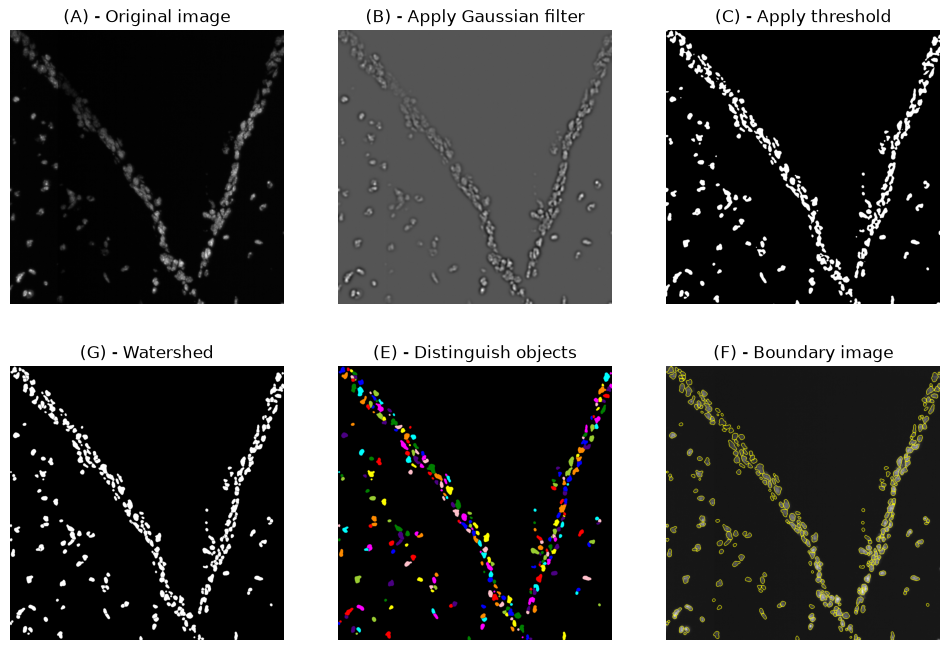

In [8]:
import numpy as np
from scipy import ndimage
from skimage.filters import threshold_triangle
from skimage.filters import threshold_otsu
from skimage.morphology import disk,extrema
from skimage.segmentation import watershed, mark_boundaries
from skimage.color import label2rgb
from skimage.measure import regionprops, regionprops_table
from matplotlib import pyplot as plt
from skimage import io
from skimage.io import imread

# Read image
path = '/Users/chann/Downloads/F1 Systems bio/Project/code/realistic_data/selected-tiles/out_opt_flow_registered_X10_Y2_c01_DAPI.tif'
im = io.imread(path).astype(np.float32)


# Apply difference of Gaussian filter
sigma1 = 3
sigma2 = 3*1.6
im_dog = ndimage.gaussian_filter (im,sigma1)  - ndimage.gaussian_filter(im,sigma2)

# Threshold for spot detection # use otsu
bw_spots = im_dog > threshold_triangle(im_dog)


# Clean up with morphological opening
structure_element = disk(3)
bw_spots_opened = ndimage.binary_opening(bw_spots, structure = structure_element) #erosion (delete small noise) => dilation (expand the remaining part)-> original size

# Distance and watershed - based split
bw_spots_dist = ndimage.distance_transform_edt(bw_spots_opened)
bw_spots_max = extrema.h_maxima(bw_spots_dist, 0.5)
bw_spots_max = ndimage.binary_dilation(bw_spots_max, structure=np.ones((3, 3)))
bw_spots_max = np.bitwise_and(bw_spots_opened, bw_spots_max)
lab_spots, n = ndimage.label(bw_spots_max)
lab_spots = watershed(-bw_spots_dist, markers=lab_spots, mask=bw_spots_opened, watershed_line=True)
bw_spots_cleaned = lab_spots > 0

# Distinguish objects
dist_image = label2rgb(lab_spots, bg_label = 0, bg_color = 'black')


# Boundaries
#boundary_image = mark_boundaries(np.clip(im_rgb, 0, 1), lab_spots, mode='thick')
from skimage.color import gray2rgb

im_norm = im / im.max()  # normalize to [0,1]
im_rgb = gray2rgb(im_norm)
boundary_image = mark_boundaries(im_rgb, lab_spots, mode='thick')

#Count the number
n_spots = lab_spots.max()
print(n_spots)

# Show images

fig, axes = plt.subplots(2,3, figsize = (12,8))
axes  = axes.ravel()

axes[0].imshow(im, cmap = 'gray')
axes[0].set_title ('(A) - Original image')
axes[0].axis('off')

axes[1].imshow(im_dog,cmap = 'gray')
axes[1].set_title('(B) - Apply Gaussian filter')
axes[1].axis('off')

axes[2].imshow(bw_spots, cmap = 'gray')
axes[2].set_title('(C) - Apply threshold')
axes[2].axis('off')

axes[3].imshow(bw_spots_cleaned, cmap = 'gray')
axes[3].set_title('(G) - Watershed')
axes[3].axis('off')

axes[4].imshow(dist_image)
axes[4].set_title('(E) - Distinguish objects')
axes[4].axis('off')

axes[5].imshow(boundary_image)
axes[5].set_title('(F) - Boundary image')
axes[5].axis('off')




lab_spots = watershed(-bw_spots_dist, markers = lab_spots, mask =bw_image_cleanup,  watershed_line=True) <br>
mask => water is allowed to expand inside the (bw_image_cleanup) range. - not expanding to background <br>




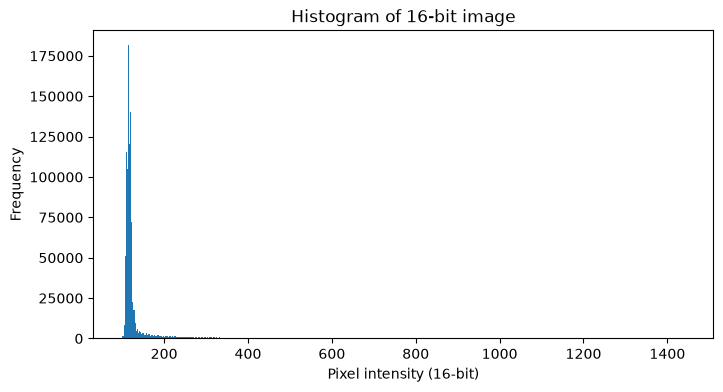

Number of nuclei after thresholding: 241
Number of nuclei after morphological opening: 233
Number of seeds: 369
Number of nuclei after watershed:369
Before filtering: 369 nuclei
After filtering (area > 50): 366 nuclei


<Figure size 800x400 with 0 Axes>

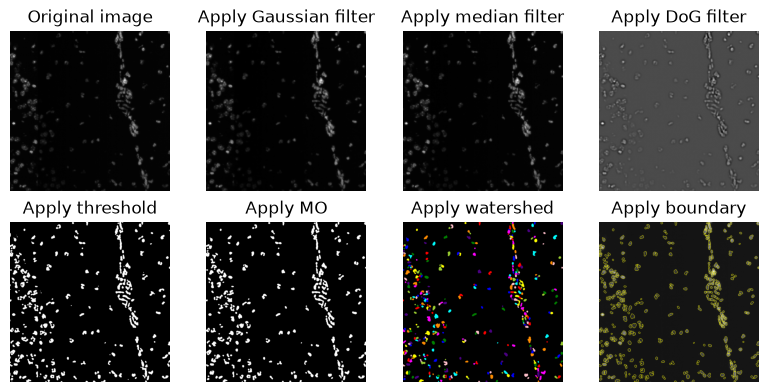

In [3]:
#31/8/2026 - X10_Y3_c01

import matplotlib.pyplot as plt
import numpy as np
from skimage import io
from skimage.io import imread
from skimage.filters import threshold_triangle
from skimage.filters import threshold_otsu

#Read and show image => Original image
path = '/Users/chann/Downloads/F1 Systems bio/Project/code/realistic_data/selected-tiles/out_opt_flow_registered_X10_Y3_c01_DAPI.tif'
im = io.imread(path).astype(np.float32)

#Create the histogram => see the overall structure => 1 peaks => triangle thresholding <> two peak => otsu
fig = plt.figure(figsize=(8, 4))

im_hist = plt.hist(im.ravel(), bins=512, range=(im.min(), im.max()))  #the darkest value and brightest value of pixel
plt.xlabel('Pixel intensity (16-bit)')
plt.ylabel('Frequency')
plt.title('Histogram of 16-bit image')
plt.show()

# Apply median filter => delete salt pepper noise
from scipy import ndimage

im_median = ndimage.median_filter(im, size=3)

#Apply gaussian filter => still have salt pepper noise => apply gaussian filter
#Note that: sigma value corresponding to blurry
from skimage import filters

plt.figure(figsize=(8, 4))
im_gauss = filters.gaussian(im_median, sigma=1)

#Apply difference of Gaussian filter (1)
from skimage.filters import difference_of_gaussians

im_dog = difference_of_gaussians(im_gauss, low_sigma=3, high_sigma=3 * 1.6)

#Apply thresholding => still have salt pepper noise and connected nuclei
# -> apply gaussian filter(1)
from skimage.filters import threshold_triangle

im_threshold = im_dog > threshold_triangle(im_dog)

#Count the number of nuclei after thresholding: to check number of nuclei before and after morphological opening
from scipy import ndimage

labeled_array, num_features = ndimage.label(im_threshold)
print(f"Number of nuclei after thresholding: {num_features}")

#Apply morphological opening:
#still have noise -> use erosion and dilation to solve it. Necessary thing when we'll do watershed
from skimage.morphology import disk, extrema  #Disk: create the circular structure element <> extrema: min, max

structure_element = disk(3)
im_opened = ndimage.binary_opening(im_threshold, structure=structure_element)

labeled_array, num_features = ndimage.label(im_opened)
print(f'Number of nuclei after morphological opening: {num_features}')

#Apply watershed
from scipy.ndimage import distance_transform_edt
from skimage.color import label2rgb
from skimage import filters

## Distance transform => calculate the distance from bright spot to the closest black spots.
im_dist = distance_transform_edt(im_opened)
im_dist = np.round(im_dist)

## Define the seed: There is a lot of tiny maxima (included noise) -> we use H - maxima to find only the larger maximan => dilate them to resist the too much close distance between seeds.
from skimage.morphology import extrema

im_maxima = extrema.h_maxima(im_dist, 0.5)
im_maxima = ndimage.binary_dilation(im_maxima)
im_maxima = im_maxima & im_opened  #set the limitation -> make sure we will not dilate them beyond the boundary of image
lab_seeds, n = ndimage.label(
    im_maxima)  #count and give them ID => lab_seeds is the result after giving them ID(array) -> n= total number of seeds(integer)
labeled_array, num_features = ndimage.label(im_maxima)
print(f'Number of seeds: {n}')

## Apply the watershed
from skimage.segmentation import watershed

im_water = watershed(im_maxima, markers=lab_seeds, mask=im_opened, watershed_line=True)

print(f'Number of nuclei after watershed:{n}')

# Apply boundary
from skimage.segmentation import mark_boundaries
from skimage.color import gray2rgb

im_norm = im / im.max()  # normalize to [0,1]
im_rgb = gray2rgb(im_norm)
im_bound = mark_boundaries(im_rgb, im_water, mode='median')

#export nuclei coordinates
from skimage.measure import regionprops_table
import pandas as pd

props = regionprops_table(im_water, properties=['label', 'centroid', 'area'])
df = pd.DataFrame(props)

df_filtered = df[df['area'] > 50].copy()

print(f"Before filtering: {len(df)} nuclei")
print(f"After filtering (area > 50): {len(df_filtered)} nuclei")

df_filtered.to_csv('nuclei_coordinates_X10_Y3_c01.csv', index=False)


#Show image
def create_figure(figsize=(8, 4)):
    return plt.figure(figsize=figsize)


def show_image(img, title='', pos=111, cmap='gray'):
    plt.subplot(pos)
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis('off')


def glue_fig(name, fig):
    plt.tight_layout()
    plt.savefig(f"{name}.png")
    plt.show()


fig = create_figure(figsize=(8, 4))

show_image(im, title='Original image', pos=241)
show_image(im_gauss, title='Apply Gaussian filter', pos=242, cmap='gray')
show_image(im_median, title='Apply median filter', pos=243, cmap='gray')
show_image(im_dog, title='Apply DoG filter', pos=244, cmap='gray')
show_image(im_threshold, title='Apply threshold', pos=245, cmap='gray')
show_image(im_opened, title='Apply MO', pos=246, cmap='gray')
show_image(label2rgb(im_water, bg_label=0, bg_color='black'), title='Apply watershed', pos=247)
show_image(im_bound, title='Apply boundary', pos=248, cmap='gray')

glue_fig('fig_overview_workflow', fig)

Number of nuclei after thresholding: 219
Number of nuclei after morphological opening: 206
Number of seeds: 319
Number of nuclei after watershed:319
Before filtering: 319 nuclei
After filtering (area > 50): 314 nuclei


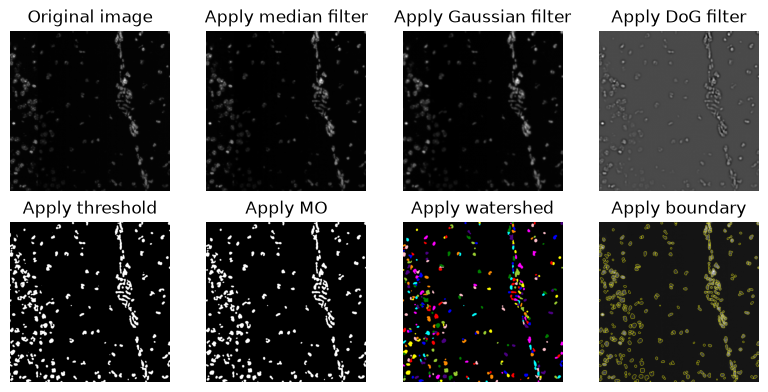

In [1]:
#31/8/2026 - X10_Y3_c01 - fixed - blurr sigma = 2

import matplotlib.pyplot as plt
import numpy as np
from skimage import io
from skimage.io import imread
from skimage.filters import threshold_triangle
from skimage.filters import threshold_otsu
from scipy import ndimage
from skimage import filters
from skimage import filters
from skimage.filters import difference_of_gaussians
from scipy import ndimage
from skimage.morphology import disk, extrema
from skimage.segmentation import watershed
from scipy.ndimage import distance_transform_edt
from skimage.color import label2rgb
from skimage.segmentation import mark_boundaries
from skimage.color import gray2rgb
from skimage.measure import regionprops_table
import pandas as pd

#Read and show image => Original image
path = '/Users/chann/Downloads/F1 Systems bio/Project/code/realistic_data/selected-tiles/out_opt_flow_registered_X10_Y3_c01_DAPI.tif'
im = io.imread(path).astype(np.float32)

# Apply median filter => delete salt pepper noise
from skimage.filters import median
im_median = median(im, disk(3))

# Apply Gaussian filter => delete salt pepper noise
im_gauss = filters.gaussian(im_median, sigma=2)

#Apply difference of Gaussian filter (1)
im_dog = difference_of_gaussians(im_gauss, low_sigma=3, high_sigma=3 * 1.6)

#Apply thresholding => still have salt pepper noise and connected nuclei
# -> apply gaussian filter(1)
im_threshold = im_dog > threshold_triangle(im_dog)

#Count the number of nuclei after thresholding: to check number of nuclei before and after morphological opening
labeled_array, num_features = ndimage.label(im_threshold)
print(f"Number of nuclei after thresholding: {num_features}")

#Apply morphological opening:
#still have noise -> use erosion and dilation to solve it. Necessary thing when we'll do watershed
structure_element = disk(3)
im_opened = ndimage.binary_opening(im_threshold, structure=structure_element)
labeled_array, num_features = ndimage.label(im_opened)
print(f'Number of nuclei after morphological opening: {num_features}')

#Apply watershed

## Distance transform => calculate the distance from bright spot to the closest black spots.
im_dist = distance_transform_edt(im_opened)
im_dist = np.round(im_dist)

## Define the seed: There is a lot of tiny maxima (included noise) -> we use H - maxima to find only the larger maxima => dilate them to resist the too much close distance between seeds.
im_maxima = extrema.h_maxima(im_dist, 0.5)
im_maxima = ndimage.binary_dilation(im_maxima)
im_maxima = im_maxima & im_opened  #set the limitation -> make sure we will not dilate them beyond the boundary of image
lab_seeds, n = ndimage.label(im_maxima)  #count and give them ID => lab_seeds is the result after giving them ID(array) -> n= total number of seeds(integer)
labeled_array, num_features = ndimage.label(im_maxima)
print(f'Number of seeds: {n}')

## Apply the watershed
im_water = watershed(im_maxima, markers=lab_seeds, mask=im_opened, watershed_line=True)
print(f'Number of nuclei after watershed:{n}')

# Apply boundary
im_norm = im / im.max()  # normalize to [0,1]
im_rgb = gray2rgb(im_norm)
im_bound = mark_boundaries(im_rgb, im_water, mode='median')

#export nuclei coordinates
props = regionprops_table(im_water, properties=['label', 'centroid', 'area'])
df = pd.DataFrame(props)
df_filtered = df[df['area'] > 50].copy()

print(f"Before filtering: {len(df)} nuclei")
print(f"After filtering (area > 50): {len(df_filtered)} nuclei")

#Show image
def create_figure(figsize=(8, 4)):
    return plt.figure(figsize=figsize)


def show_image(img, title='', pos=111, cmap='gray'):
    plt.subplot(pos)
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis('off')


def glue_fig(name, fig):
    plt.tight_layout()
    plt.savefig(f"{name}.png")
    plt.show()


fig = create_figure(figsize=(8, 4))

show_image(im, title='Original image', pos=241)
show_image(im_median, title='Apply median filter', pos=242, cmap='gray')
show_image(im_gauss, title='Apply Gaussian filter', pos=243, cmap='gray')
show_image(im_dog, title='Apply DoG filter', pos=244, cmap='gray')
show_image(im_threshold, title='Apply threshold', pos=245, cmap='gray')
show_image(im_opened, title='Apply MO', pos=246, cmap='gray')
show_image(label2rgb(im_water, bg_label=0, bg_color='black'), title='Apply watershed', pos=247)
show_image(im_bound, title='Apply boundary', pos=248, cmap='gray')
glue_fig('fig_overview_workflow', fig)

In [16]:
import glob
import skimage
path = '/Users/chann/Downloads/F1 Systems bio/Project/code/realistic_data/selected-tiles/'
#file_list = glob.glob('/Users/chann/Downloads/F1 Systems bio/Project/code/realistic_data/selected-tiles/out_opt_flow_registered_X10_Y10_*DAPI.tif')
paths = sorted(glob.glob(f'{PATH}/out_opt_flow_registered_X10_Y10_*DAPI.tif'))
print(dapi_path) # have not sorted -> need to sort



['/Users/chann/Downloads/F1 Systems bio/Project/code/realistic_data/selected-tiles/out_opt_flow_registered_X10_Y10_c01_DAPI.tif', '/Users/chann/Downloads/F1 Systems bio/Project/code/realistic_data/selected-tiles/out_opt_flow_registered_X10_Y10_c02_DAPI.tif', '/Users/chann/Downloads/F1 Systems bio/Project/code/realistic_data/selected-tiles/out_opt_flow_registered_X10_Y10_c03_DAPI.tif', '/Users/chann/Downloads/F1 Systems bio/Project/code/realistic_data/selected-tiles/out_opt_flow_registered_X10_Y10_c04_DAPI.tif']


In [5]:
import glob
import os
import numpy as np
import pandas as pd
from skimage import io, filters
from skimage.filters import threshold_triangle, difference_of_gaussians
from skimage.morphology import disk, extrema
from skimage.measure import regionprops_table
from skimage.segmentation import watershed
from scipy import ndimage
from scipy.ndimage import distance_transform_edt
from skimage.color import label2rgb, gray2rgb
from skimage.segmentation import mark_boundaries
import matplotlib.pyplot as plt

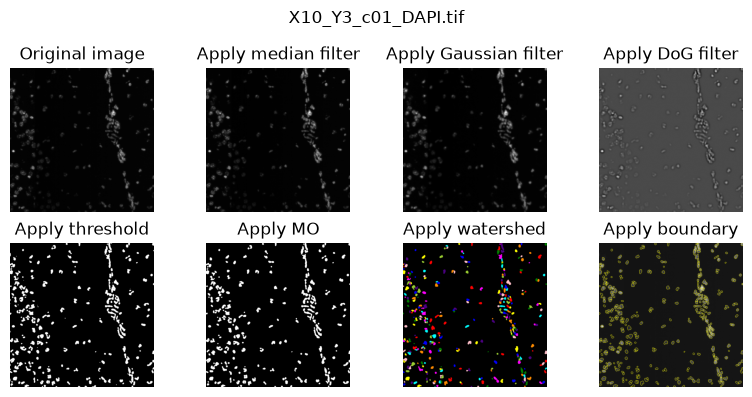

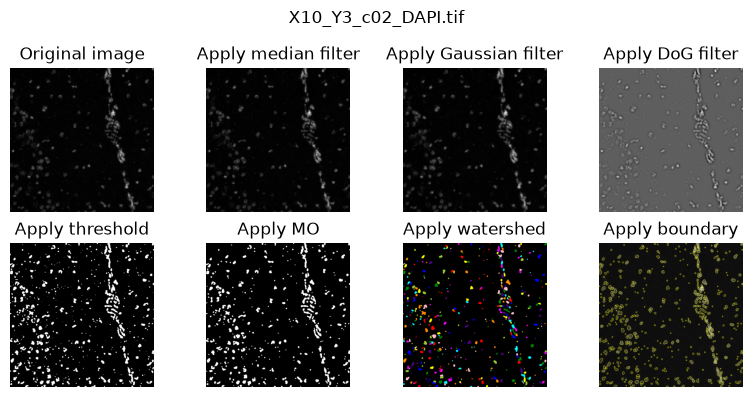

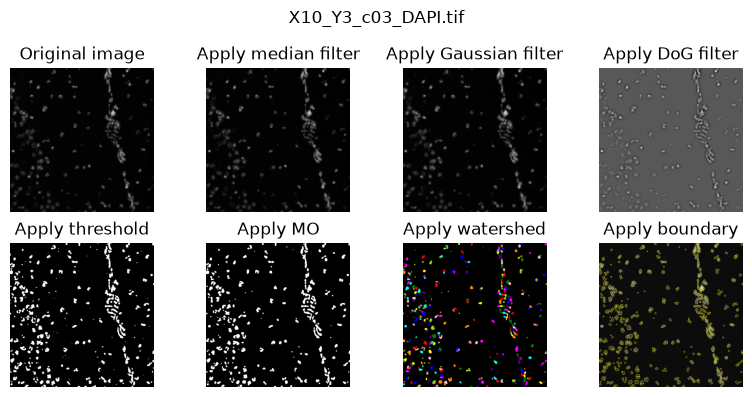

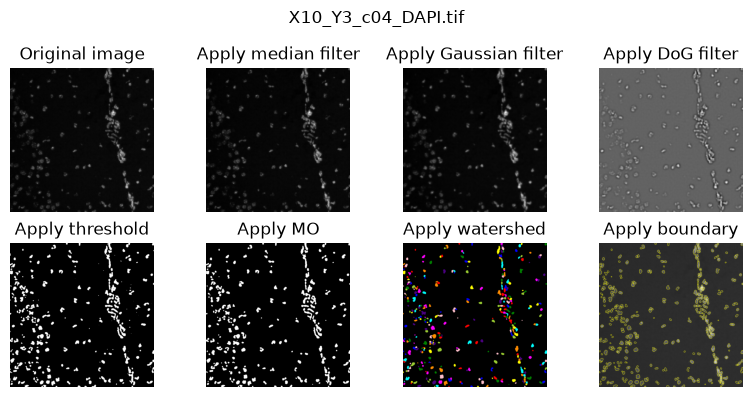

     Name  Round1  Round2  Round3  Round4   Mean
0  X10_Y3     339     440     366     343  372.0


In [6]:

folder = '/Users/chann/Downloads/F1 Systems bio/Project/code/realistic_data/selected-tiles/'

MEDIAN_SIZE = 3
GAUSSIAN_SIGMA = 2
DOG_LOW_SIGMA = 3
DOG_HIGH_SIGMA = DOG_LOW_SIGMA * 1.6
DISK_RADIUS = 3
H_MAXIMA_THRESHOLD = 0.5
AREA_MIN = 50

# 1 DAPI image
def count_nuclei_one_round(image_path): #only use in function
    im = io.imread(image_path).astype(np.float32)
    im_median = ndimage.median_filter(im, size=MEDIAN_SIZE)
    im_gauss = filters.gaussian(im_median, sigma=GAUSSIAN_SIGMA)
    im_dog = difference_of_gaussians(im_gauss, low_sigma=DOG_LOW_SIGMA, high_sigma=DOG_HIGH_SIGMA)
    im_threshold = im_dog > threshold_triangle(im_dog)
    im_opened = ndimage.binary_opening(im_threshold, structure=disk(DISK_RADIUS))

    im_dist = np.round(distance_transform_edt(im_opened))
    im_maxima = extrema.h_maxima(im_dist, H_MAXIMA_THRESHOLD)
    im_maxima = ndimage.binary_dilation(im_maxima) & im_opened
    lab_seeds, n = ndimage.label(im_maxima)

    im_water = watershed(im_maxima, markers=lab_seeds, mask=im_opened, watershed_line=True)
    im_norm = im / im.max()  # normalize to [0,1]
    im_rgb = gray2rgb(im_norm)
    im_bound = mark_boundaries(im_rgb, im_water, mode='median')
    im_name = image_path.split("registered_")[-1]

    df = pd.DataFrame(regionprops_table(im_water, properties=['label', 'centroid', 'area']))
    return len(df), im, im_median, im_gauss, im_dog, im_threshold, im_opened, im_water, im_bound, im_name

#Draw plot
def show_image(img, title='', pos=111, cmap='gray'):
    plt.subplot(pos)
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis('off')

def glue_fig(name, fig):
    plt.tight_layout()
    plt.savefig(f"/Users/chann/Downloads/F1 Systems bio/Project/code/Results/Figures/{name}.png", bbox_inches="tight")
    plt.show()

def im_plot(im, im_median, im_gauss, im_dog, im_threshold, im_opened, im_water, im_bound, im_name):
    fig = plt.figure(figsize=(8, 4))
    fig.suptitle(im_name) # supertitle for big fig

    show_image(im, title='Original image', pos=241)
    show_image(im_median, title='Apply median filter', pos=242, cmap='gray')
    show_image(im_gauss, title='Apply Gaussian filter', pos=243, cmap='gray')
    show_image(im_dog, title='Apply DoG filter', pos=244, cmap='gray')
    show_image(im_threshold, title='Apply threshold', pos=245, cmap='gray')
    show_image(im_opened, title='Apply MO', pos=246, cmap='gray')
    show_image(label2rgb(im_water, bg_label=0, bg_color='black'), title='Apply watershed', pos=247)
    show_image(im_bound, title='Apply boundary', pos=248, cmap='gray')

    glue_fig(f'fig_overview_workflow{im_name}', fig)


# 4 DAPI images
def count_nuclei(folder_path):
    nuclei_counts_dict = {}
    paths = sorted(glob.glob(folder_path + 'out_opt_flow_registered_X10_Y3_c*_DAPI.tif'))#list of paths satisfied above condition
    counts = [] # list of number of nuclei per DAPI image
    ims = [] # list of  big images - contain 4 images
    for path in paths: #
        plot_result = [] #contain 8 images in current round
        len_df, im, im_median, im_gauss, im_dog, im_threshold, im_opened, im_water, im_bound, im_name = count_nuclei_one_round(path)
        plot_result.append(im)
        plot_result.append(im_median)
        plot_result.append(im_gauss)
        plot_result.append(im_dog)
        plot_result.append(im_threshold)
        plot_result.append(im_opened)
        plot_result.append(im_water)
        plot_result.append(im_bound)
        plot_result.append(im_name) #im_name
        ims.append(plot_result)
        counts.append(len_df)
        nuclei_counts_dict[path.split("registered_")[-1]] = len_df
    nuclei_counts_dict['mean'] = np.mean(counts)

    #Plot image
    for (im, im_median, im_gauss, im_dog, im_threshold, im_opened, im_water, im_bound, im_name) in ims: #visualization
        im_plot(im, im_median, im_gauss, im_dog, im_threshold, im_opened, im_water, im_bound, im_name)
    return nuclei_counts_dict,counts

#Number of nuclei
result_nuclei, counts = count_nuclei(folder)

# Take name of fov from fictionary
image_keys = list(result_nuclei.keys())
image_keys.remove("mean")
fov_name = image_keys[0].split("_c")[0] # from"X10_Y3_c04_DAPI.tif => separate 2 part at 'c' position => take only X10_Y3

row_data = {
    "Name": fov_name,
    "Round1": result_nuclei[image_keys[0]],
    "Round2": result_nuclei[image_keys[1]],
    "Round3": result_nuclei[image_keys[2]],
    "Round4": result_nuclei[image_keys[3]],
    "Mean": result_nuclei["mean"],} #collect the data => put into dictionary -before putting in csv file => purpuse: key => heading, value -> row1

df_result = pd.DataFrame([row_data])
df_result.to_csv("/Users/chann/Downloads/F1 Systems bio/Project/code/Results/nuclei_counts_full.csv",index=False,)

print(df_result)



for path in paths: for each image in list paths => image processing => saved the result (each image) in plot_result => add plot_result into big list ims <br>
for i in ims:visualization: iterate each set of image (saved in ims) => call im_plot -> render the image to screen


In [ ]:
# all of C01 DAPI images # PROBLEM: TOO LONG TIME FOR EXECUTING

# take the path of folder
folder = "/Users/chann/Downloads/F1 Systems bio/Project/code/realistic_data/selected-tiles/"
saved_image_path = '/Users/chann/Downloads/F1 Systems bio/Project/code/Results/Figures'
#os.makedirs(saved_image_path, exist_ok=True)

MEDIAN_SIZE = 3
GAUSSIAN_SIGMA = 2
DOG_LOW_SIGMA = 3
DOG_HIGH_SIGMA = DOG_LOW_SIGMA * 1.6
DISK_RADIUS = 3
H_MAXIMA_THRESHOLD = 0.5
AREA_MIN = 50


# Show image
def create_figure(figsize=(8, 4)):
    return plt.figure(figsize=figsize)


def show_image(img, title='', pos=111, cmap='gray'):
    plt.subplot(pos)
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis('off')


def glue_fig(name, fig):
    plt.tight_layout()
    plt.savefig(f"{name}.png")
    plt.close(fig)


# 1 DAPI image
def count_c01_nuclei(image_path, fov_name):
    im = io.imread(image_path).astype(np.float32)

    im_median = ndimage.median_filter(im, size=MEDIAN_SIZE)
    im_gauss = filters.gaussian(im_median, sigma=GAUSSIAN_SIGMA)
    im_dog = difference_of_gaussians(im_gauss, low_sigma=DOG_LOW_SIGMA, high_sigma=DOG_HIGH_SIGMA)
    im_threshold = im_dog > threshold_triangle(im_dog)
    im_opened = ndimage.binary_opening(im_threshold, structure=disk(DISK_RADIUS))
    im_dist = np.round(distance_transform_edt(im_opened))
    im_maxima = extrema.h_maxima(im_dist, H_MAXIMA_THRESHOLD)
    im_maxima = ndimage.binary_dilation(im_maxima) & im_opened
    lab_seeds, _ = ndimage.label(im_maxima)
    im_water = watershed(im_maxima, markers=lab_seeds, mask=im_opened, watershed_line=True)

    # Filtering (area > 50)
    props = regionprops_table(im_water, properties=["label", "centroid", "area"])
    df = pd.DataFrame(props)
    df_filtered = df[df["area"] > AREA_MIN]

    # Save image
    fig = create_figure(figsize=(8, 4))
    show_image(im, title='Original image', pos=241)
    show_image(im_median, title='Apply median filter', pos=242, cmap='gray')
    show_image(im_gauss, title='Apply Gaussian filter', pos=243, cmap='gray')
    show_image(im_dog, title='Apply DoG filter', pos=244, cmap='gray')
    show_image(im_threshold, title='Apply threshold', pos=245, cmap='gray')
    show_image(im_opened, title='Apply MO', pos=246, cmap='gray')
    show_image(label2rgb(im_water, bg_label=0, bg_color='black'), title='Apply watershed', pos=247)
    show_image(im_water > 0, title='Apply boundary', pos=248, cmap='gray')
    glue_fig(os.path.join(saved_image_path, f"{fov_name}_overview"), fig)

    return len(df_filtered)


# Get all c01 DAPI images
c01_paths = sorted(glob.glob(folder + "*_c01_DAPI.tif"))
results = []

for path in c01_paths:
    filename = os.path.basename(path)
    fov_name = filename.split("registered_")[-1].split("_c")[0]
    nuclei_count = count_c01_nuclei(path, fov_name)
    results.append({"FOV": fov_name, "Round1_Count": nuclei_count})

# Create data frame => save as csv
df_results = pd.DataFrame(results)
output_path = os.path.join(saved_image_path, "nuclei_counts_c01_only.csv")
df_results.to_csv(output_path, index=False)

print(df_results)

In [37]:

# take the path of folder
folder = "/Users/chann/Downloads/F1 Systems bio/Project/code/realistic_data/selected-tiles/"

MEDIAN_SIZE = 3
GAUSSIAN_SIGMA = 2
DOG_LOW_SIGMA = 3
DOG_HIGH_SIGMA = DOG_LOW_SIGMA * 1.6
DISK_RADIUS = 3
H_MAXIMA_THRESHOLD = 0.5
AREA_MIN = 50


# 1 DAPI image
def count_c01_nuclei(image_path):
    im = io.imread(image_path).astype(np.float32)

    im_median = ndimage.median_filter(im, size=MEDIAN_SIZE)
    im_gauss = filters.gaussian(im_median, sigma=GAUSSIAN_SIGMA)
    im_dog = difference_of_gaussians(im_gauss, low_sigma=DOG_LOW_SIGMA, high_sigma=DOG_HIGH_SIGMA)
    im_threshold = im_dog > threshold_triangle(im_dog)
    im_opened = ndimage.binary_opening(im_threshold, structure=disk(DISK_RADIUS))
    im_dist = np.round(distance_transform_edt(im_opened))
    im_maxima = extrema.h_maxima(im_dist, H_MAXIMA_THRESHOLD)
    im_maxima = ndimage.binary_dilation(im_maxima) & im_opened
    lab_seeds, _ = ndimage.label(im_maxima)
    im_water = watershed(im_maxima, markers=lab_seeds, mask=im_opened, watershed_line=True)

    # Filtering (area > 50)
    props = regionprops_table(im_water, properties=["label", "centroid", "area"])
    df = pd.DataFrame(props)
    df_filtered = df[df["area"] > AREA_MIN]

    return len(df_filtered)


# Get all round 1 images
c01_paths = sorted(glob.glob(folder + "*_c01_DAPI.tif"))
results = []

for path in c01_paths:
    filename = os.path.basename(path)
    fov_name = filename.split("registered_")[-1].split("_c")[0]
    nuclei_count = count_c01_nuclei(path)
    results.append({"FOV": fov_name, "Round1_Count": nuclei_count})

# Create data frame => save as csv
df_results = pd.DataFrame(results)
output_path = "/Results/Intermediates/nuclei_counts_c01_only.csv"
df_results.to_csv(output_path, index=False)

print(df_results)

         FOV  Round1_Count
0    X10_Y10           318
1    X10_Y11           385
2    X10_Y12           508
3    X10_Y13           460
4    X10_Y14           373
..       ...           ...
185   X23_Y4             1
186   X23_Y5            51
187   X23_Y6            84
188   X23_Y7            74
189   X23_Y8            54

[190 rows x 2 columns]


In [2]:
# import glob
# import numpy as np
# import pandas as pd
# from skimage import io, filters
# from skimage.filters import threshold_triangle, difference_of_gaussians
# from skimage.morphology import disk, extrema
# from skimage.measure import regionprops_table
# from skimage.segmentation import watershed
# from scipy import ndimage
# from scipy.ndimage import distance_transform_edt
# from skimage.color import label2rgb, gray2rgb
# from skimage.segmentation import mark_boundaries
# import matplotlib.pyplot as plt

folder = '/Users/chann/Downloads/F1 Systems bio/Project/code/realistic_data/selected-tiles/'

MEDIAN_SIZE = 3
GAUSSIAN_SIGMA = 2
DOG_LOW_SIGMA = 3
DOG_HIGH_SIGMA = DOG_LOW_SIGMA * 1.6
DISK_RADIUS = 3
H_MAXIMA_THRESHOLD = 0.5
AREA_MIN = 50


# 1 DAPI image
def count_nuclei_one_round(image_path):  #only use in function
    im = io.imread(image_path).astype(np.float32)
    im_median = ndimage.median_filter(im, size=MEDIAN_SIZE)
    im_gauss = filters.gaussian(im_median, sigma=GAUSSIAN_SIGMA)
    im_dog = difference_of_gaussians(im_gauss, low_sigma=DOG_LOW_SIGMA, high_sigma=DOG_HIGH_SIGMA)
    im_threshold = im_dog > threshold_triangle(im_dog)
    im_opened = ndimage.binary_opening(im_threshold, structure=disk(DISK_RADIUS))

    im_dist = np.round(distance_transform_edt(im_opened))
    im_maxima = extrema.h_maxima(im_dist, H_MAXIMA_THRESHOLD)
    im_maxima = ndimage.binary_dilation(im_maxima) & im_opened
    lab_seeds, n = ndimage.label(im_maxima)

    im_water = watershed(im_maxima, markers=lab_seeds, mask=im_opened, watershed_line=True)
    im_norm = im / im.max()  # normalize to [0,1]
    im_rgb = gray2rgb(im_norm)
    im_bound = mark_boundaries(im_rgb, im_water, mode='median')
    im_name = image_path.split("registered_")[-1]

    df = pd.DataFrame(regionprops_table(im_water, properties=['label', 'centroid', 'area']))
    return len(df), im, im_median, im_gauss, im_dog, im_threshold, im_opened, im_water, im_bound, im_name


# 4 DAPI images
def count_nuclei(folder_path, fov):
    nuclei_counts_dict = {}
    paths = sorted(glob.glob(folder_path + f'out_opt_flow_registered_{fov}_c*_DAPI.tif'))  #list of paths satisfied above condition
    counts = []
    for path in paths:
        len_df, im, im_median, im_gauss, im_dog, im_threshold, im_opened, im_water, im_bound, im_name = count_nuclei_one_round(
            path)

        counts.append(len_df)
        nuclei_counts_dict[path.split("registered_")[-1].split('_')[2]] = len_df
    nuclei_counts_dict['mean'] = np.mean(counts)
    nuclei_counts_dict['name'] = fov

    return nuclei_counts_dict

In [3]:

#Number of nuclei
result_nuclei = [
    count_nuclei(folder,'X11_Y3'),
    count_nuclei( folder, 'X20_Y3'),
    count_nuclei(folder,'X10_Y3'),
    count_nuclei( folder, 'X10_Y12'),
    count_nuclei(folder,'X10_Y8'),
]


In [4]:
pd.DataFrame(result_nuclei)


,c01,c02,c03,c04,mean,name
0,452,547,433,426,464.50,X11_Y3
1,429,521,466,436,463.00,X20_Y3
2,339,440,366,343,372.00,X10_Y3
3,521,572,548,525,541.50,X10_Y12
4,457,579,502,457,498.75,X10_Y8


In [1]:
#Import library

import matplotlib.pyplot as plt
import pandas as pd
import glob
import numpy as np
import skimage
from scipy import ndimage
from skimage import io, filters
from skimage import morphology
from skimage.morphology import disk, extrema
from skimage.filters import median, gaussian, threshold_triangle, difference_of_gaussians
from scipy.ndimage import distance_transform_edt
from skimage.segmentation import watershed
from skimage.color import label2rgb, gray2rgb
from skimage.segmentation import mark_boundaries
from skimage.measure import regionprops_table


In [2]:
#Apply global variable
DISK = 3
SIGMA = 2
LOW_SIGMA = 3
HIGH_SIGMA = LOW_SIGMA * 1.6
H_MAXIMA_THRESHOLD = 0.5
MIN_AREA = 50


In [3]:
#Count number of nuclei in 1 DAPI image

def one_image(im_path):
    #im_name = im_path.split("registered_")[-1]
    im = io.imread(im_path).astype(np.float32)
    im_mean = median(im, disk(DISK))
    im_gauss = gaussian(im_mean, sigma=SIGMA)
    im_dog = difference_of_gaussians(im_gauss, low_sigma=LOW_SIGMA, high_sigma=HIGH_SIGMA)
    im_threshold = im_dog > threshold_triangle(im_dog)
    im_open = ndimage.binary_opening(im_threshold, disk(DISK))

    im_dist = np.round(distance_transform_edt(im_open))
    im_maxima = extrema.h_maxima(im_dist, H_MAXIMA_THRESHOLD)
    im_maxima = ndimage.binary_dilation(im_maxima) & im_open
    seeds, n = ndimage.label(im_maxima)
    im_water = watershed(im_maxima, markers=seeds, mask=im_open, watershed_line=True)
    #label_image, number_features = ndimage.label(im_water)
    #im_bound = mark_boundaries(im, label_image)

    # count and filter
    df = pd.DataFrame(regionprops_table(im_water, properties=['label', 'area']))
    df_filter = df[df['area'] > MIN_AREA]
    #df.to_csv('result.csv', index = False)

    return len(df_filter)


In [4]:
path_folder = '/Users/chann/Downloads/F1 Systems bio/Project/code/realistic_data/selected-tiles/'
def cycle_from_path (path):
    return path.split("registered_")[1].split("_")[2]
def four_images(folder, fov_name):
    path_images = sorted(glob.glob(folder + f'out_opt_flow_registered_{fov_name}_c*_DAPI.tif'))
    count_images = []
    count_images_dict = {}
    for path in path_images:
        len_df = one_image(path)
        count_images.append(len_df)
        count_images_dict[cycle_from_path(path)] = len_df  #X10_Y10_c01_DAPI.tif => c01
    count_images_dict['mean'] = np.mean(count_images)
    count_images_dict['name'] = fov_name
    return count_images_dict

In [ ]:
# all of fov

#Take the list of all fov name
path_folder = '/Users/chann/Downloads/F1 Systems bio/Project/code/realistic_data/selected-tiles/'
path_fov = glob.glob(path_folder + f'out_opt_flow_registered_*_c01_DAPI.tif')

name_fov = [path.split("registered_")[1].split("_c01")[0] for path in path_fov]  #List comprehension
print(len(name_fov))

In [6]:

#Count all fov
count_all = []  #list of dict
for name in name_fov:
    fov_result = four_images(path_folder, name)
    count_all.append(fov_result)


In [ ]:

df_all = pd.DataFrame(count_all)
df_all = df_all[['name', 'c01', 'c02', 'c03', 'c04', 'mean']]
df_all.to_csv('nuclei_all.csv', index=False)



1. Flow of code: <br> 1 image -> 4 image in 1 fov  -> all of fov <br> For each function, we do one task.